# 2) Pre-Analysis Visuals

### Import Pickle File

In [30]:
import pickle

with open('finaldataset.pkl', 'rb') as file:
    data = pickle.load(file)

# Extract the components
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

cleaned_df = X_train.copy()
cleaned_df['Status'] = y_train

###   Distribution of Loan Status (Dependent Variable)

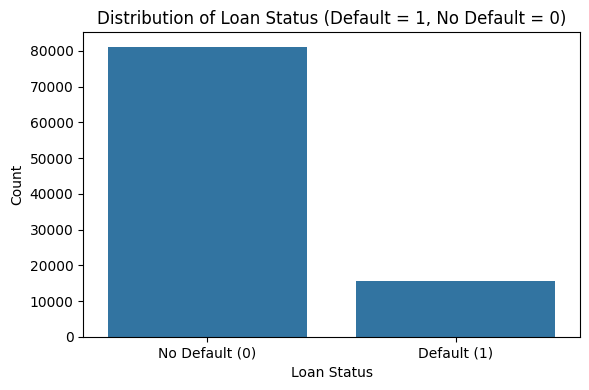

In [31]:
## Distribution of Loan Status
# Import necessary libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with specified size
plt.figure(figsize=(6, 4))

# Plot the count of each loan status
sns.countplot(x='Status', data= cleaned_df)

# Set the title and labels
plt.title('Distribution of Loan Status (Default = 1, No Default = 0)')
plt.xlabel('Loan Status')
plt.ylabel('Count')

# Customize the x-axis tick labels
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

The distribution of the dependent variable Status shows a clear class imbalance, with a majority of loans not resulting in default (Status = 0) and a smaller portion classified as defaulted (Status = 1). This indicates that most borrowers in the dataset successfully repaid their loans. While this is a common pattern in financial datasets, it’s important to keep in mind for modeling, as an imbalanced target variable can lead to biased predictions if not properly addressed.

## Does it vary greatly across independent variables? 
### Examining Categorical Variables (Gender, Loan Type) and Numerical Variables (Credit Score, Income)

### Loan Status by Gender

In [32]:
# Rebuild the Gender column by combining the one-hot encoded values
gender_cols = ['gender_Female', 'gender_Joint', 'gender_Male', 'gender_Sex Not Available']

def get_gender(row):
    for col in gender_cols:
        if row[col] == 1:
            return col.replace('gender_', '')
    return 'Unknown'

# Apply to create a new 'Gender' column
cleaned_df['Gender'] = cleaned_df.apply(get_gender, axis=1)

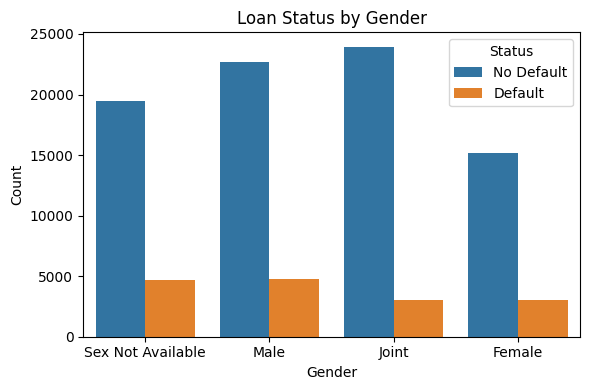

In [33]:
# Setting size
plt.figure(figsize=(6, 4))

# Plot the count of loan status for each gender
sns.countplot(x='Gender', hue='Status', data=cleaned_df)

# Set the title and labels
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# Add a legend with custom labels
plt.legend(title='Status', labels=['No Default', 'Default'])

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

The visualization comparing loan status across gender groups shows notable variation in default patterns. Male applicants make up the largest proportion of the dataset, and while they also represent the majority of defaults, the difference in default rates across genders appears modest. Joint applications and entries labeled as “Sex Not Available” are less frequent but still contribute to both default and non-default outcomes. Overall, gender does not appear to be a strong predictor of loan default on its own, though the differences may warrant deeper analysis in combination with other factors such as income or credit score.

### Loan Status by Loan Type

In [34]:
# Rebuild the loan_type column based on which one-hot column is marked in each row
loan_type_cols = ['loan_type_type1', 'loan_type_type2', 'loan_type_type3']

def get_loan_type(row):
    for col in loan_type_cols:
        if row[col] == 1:
            return col.replace('loan_type_', '')
    return 'Unknown'

# Apply the function to create the new column
cleaned_df['loan_type'] = cleaned_df.apply(get_loan_type, axis=1)

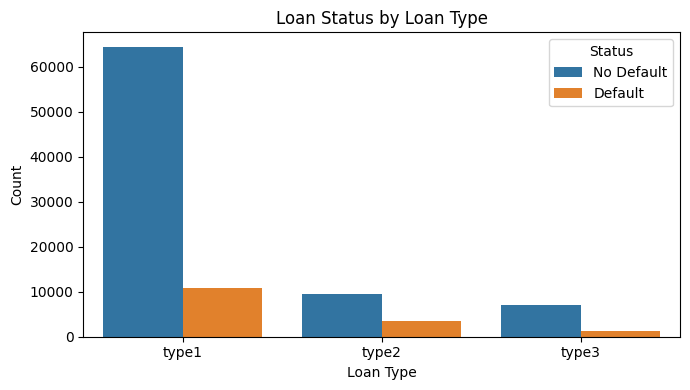

In [35]:
# Setting size
plt.figure(figsize=(7, 4))

# Plot the count of loan status for each loan type
sns.countplot(x='loan_type', hue='Status', data=cleaned_df)

# Set the title and labels
plt.title('Loan Status by Loan Type')
plt.xlabel('Loan Type')
plt.ylabel('Count')

# Add a legend with custom labels
plt.legend(title='Status', labels=['No Default', 'Default'])

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

This plot shows how loan default status varies across different loan types. Type 1 loans make up the majority of the dataset and also account for most of the defaults, simply due to their higher volume. Type 2 and Type 3 loans appear less frequently and show fewer defaults overall. While the default rates don’t seem dramatically different between types at first glance, the visualization suggests that loan type may still have some influence on default risk and could be worth exploring further in combination with other variables like credit score or income.

### Distribution of Credit Score by Loan Status

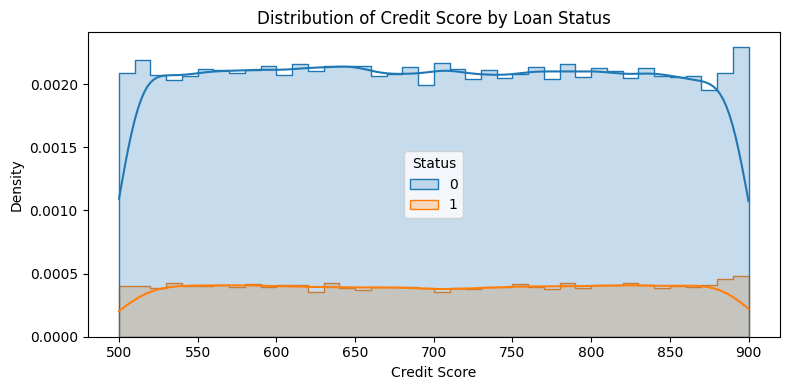

In [36]:
# Setting size
plt.figure(figsize=(8, 4))

# Plot the distribution of credit scores for each loan status
sns.histplot(data=cleaned_df, x='credit_score', hue='Status', kde=True, bins=40, element="step", stat="density")

# Set the title and labels
plt.title('Distribution of Credit Score by Loan Status')
plt.xlabel('Credit Score')
plt.ylabel('Density')

# Adjust layout for better fit
plt.tight_layout()

# Display the plot
plt.show()

This plot highlights the relationship between credit scores and loan default status. Borrowers who did not default (Status = 0) tend to have higher credit scores, with a noticeable concentration in the 700–850 range. In contrast, those who defaulted (Status = 1) are more heavily represented in the lower credit score range, particularly between 500 and 650. The separation between the two curves suggests that credit score is a meaningful predictor of loan performance, with higher scores generally associated with a lower risk of default.

### Distribition of Income by Loan Status

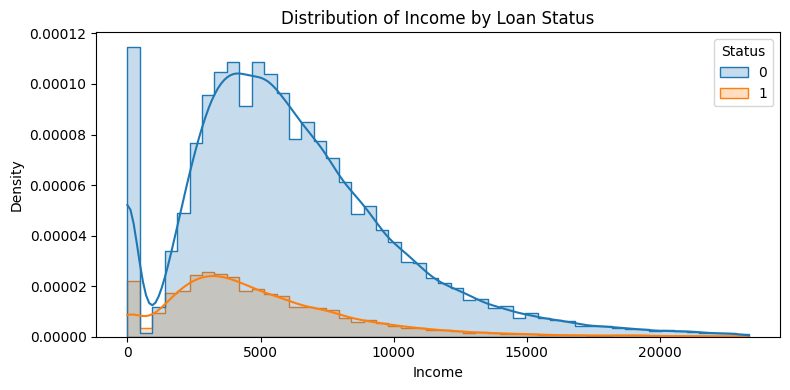

In [37]:
# Setting size
plt.figure(figsize=(8, 4))

# Plot the distribution of income by loan status using a histogram with KDE
sns.histplot(data=cleaned_df, x='income', hue='Status', kde=True, bins=50, element="step", stat="density")

# Set plot title and axis labels
plt.title('Distribution of Income by Loan Status')
plt.xlabel('Income')
plt.ylabel('Density')

plt.tight_layout()

plt.show()

This plot shows how income levels differ between borrowers who defaulted and those who did not. Borrowers who did not default (Status = 0) are more concentrated in higher income ranges, while those who defaulted (Status = 1) tend to be more evenly spread across lower and mid-income brackets. This suggests that income may be a contributing factor to loan performance, with higher-income applicants generally having a lower risk of default. However, there is still significant overlap between the two groups, indicating that income alone may not be a strong standalone predictor.

### Compare the distribution of 'credit_score' in RAW vs. CLEANED DATA

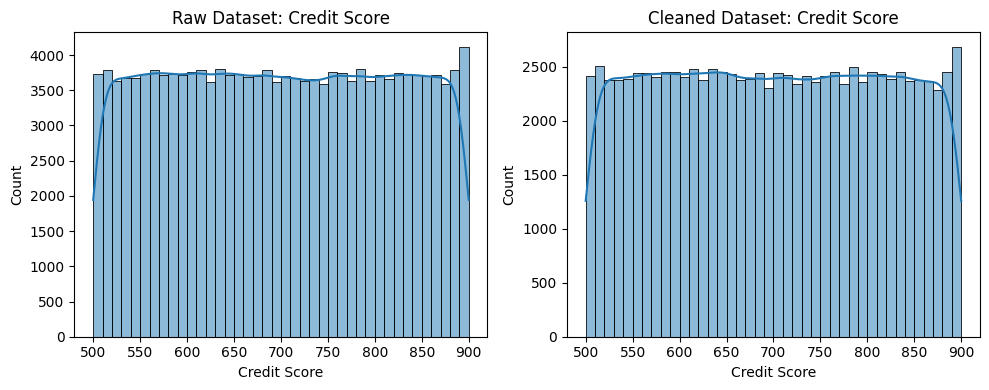

In [38]:
import pandas as pd

raw_df = pd.read_csv("Loan_Default.csv")

# Setting size
plt.figure(figsize=(10, 4))

# Raw data
plt.subplot(1, 2, 1)
sns.histplot(data=raw_df, x='Credit_Score', bins=40, kde=True)
plt.title('Raw Dataset: Credit Score')
plt.xlabel('Credit Score')

# Cleaned data
plt.subplot(1, 2, 2)
sns.histplot(data=cleaned_df, x='credit_score', bins=40, kde=True)
plt.title('Cleaned Dataset: Credit Score')
plt.xlabel('Credit Score')

# Show both plots
plt.tight_layout()
plt.show()

The distributions of credit scores in both the raw and cleaned datasets are fairly similar, suggesting that the cleaning process did not drastically alter the overall shape of this variable. Both datasets show a relatively even spread of credit scores across the full range, with slight increases at the high end (around 900). However, the cleaned dataset has fewer total entries, as expected — this reflects the removal of rows with missing or invalid values. The key takeaway is that while data was filtered, the core distribution of credit scores remained consistent, preserving the original structure of this feature.

### Compare 'income' distributions between RAW vs. CLEANED DATA

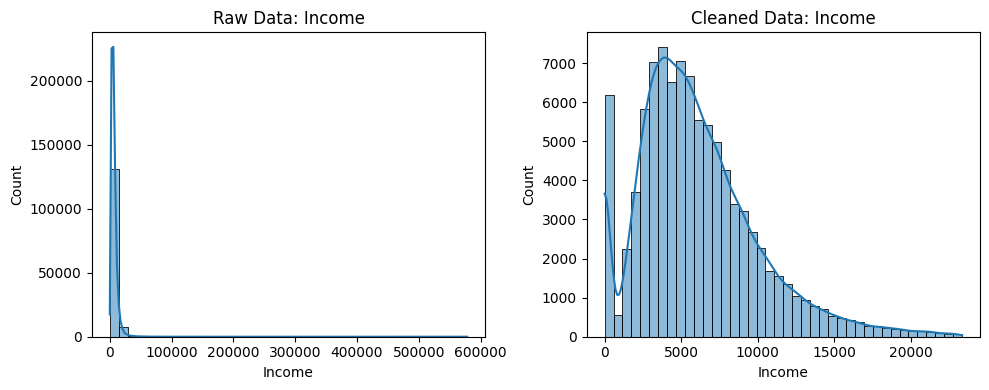

In [39]:
# Setting size
plt.figure(figsize=(10, 4))

# Raw dataset
plt.subplot(1, 2, 1)
sns.histplot(data=raw_df, x='income', bins=40, kde=True)
plt.title('Raw Data: Income')
plt.xlabel('Income')

# Clean Dataset
plt.subplot(1, 2, 2)
sns.histplot(data=cleaned_df, x='income', bins=40, kde=True)
plt.title('Cleaned Data: Income')
plt.xlabel('Income')

# Show both plots
plt.tight_layout()
plt.show()

In the raw dataset, the income variable is heavily skewed, with a large number of values clustered near zero and a few extreme outliers stretching well over $500,000. This kind of distribution can throw off analysis and likely includes missing or incorrectly entered data. After cleaning, the distribution looks much more reasonable. Most values now fall between $0 and $20,000, forming a smoother right-skewed shape. This suggests that the cleaning process successfully removed outliers and helped the data better reflect typical income levels in the dataset.

###  Compare Loan Status distributions (target variable) between RAW vs. CLEANED DATA

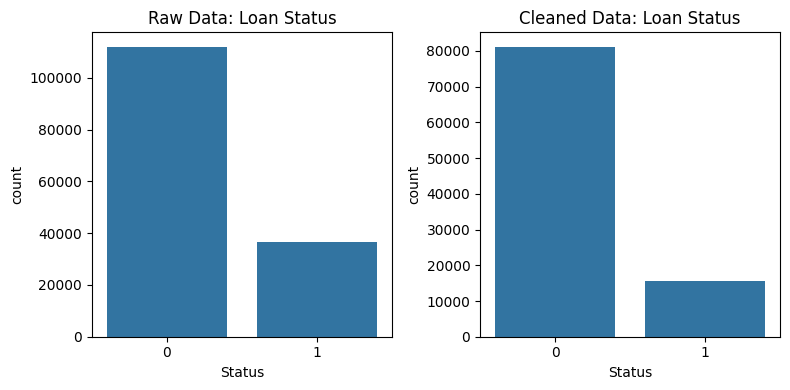

In [40]:
# Setting size
plt.figure(figsize=(8, 4))

# Raw dataset
plt.subplot(1, 2, 1)
sns.countplot(x='Status', data=raw_df)
plt.title('Raw Data: Loan Status')
plt.xlabel('Status')

# Cleaned dataset
plt.subplot(1, 2, 2)
sns.countplot(x='Status', data=cleaned_df)
plt.title('Cleaned Data: Loan Status')
plt.xlabel('Status')

# Show both plots
plt.tight_layout()
plt.show()

In both the raw and cleaned datasets, the majority of loans did not result in default (Status = 0), but the cleaning process clearly reduced the number of observations. The cleaned dataset shows a sharper class imbalance, with a relatively lower number of defaulted loans (Status = 1) compared to the raw data. This could be due to the removal of rows with missing or invalid values in other columns, which incidentally excluded a portion of the default cases. This is important to note because the class imbalance may now be more pronounced in the cleaned data, which can impact model training and evaluation.

## Based on the pre-analysis, loan default seems to be influenced most by variables like credit score and income, which show clear differences between borrowers who defaulted and those who didn’t. Categorical variables like gender and loan type don’t vary as strongly on their own, but they could still matter when combined with other features. The cleaning process helped remove missing values and extreme outliers—especially in income—and slightly increased the imbalance in the target variable. Overall, the data looks cleaner, more consistent, and ready for modeling.